# Interval Sampling Cross-Rotation 8 Samples Processed ROI

This notebook:
1. scans all 8 sample folders under `interval sampled/`
2. interval-samples each sample/classification to a maximum of `200`
3. creates `8` cross-rotation folds
4. rewrites each split CSV `file_destination` to the matching file under `processed_hsv_lab_threshold_roi_224/`

Default outputs:
- sampled CSVs: `csv_outputs_interval_sampled_v5/`
- split CSVs: `generated_splits/cross_rotation_interval200_8samples_processed_roi/`


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from sample_interval_cross_rotation_pipeline import (
    discover_sample_dirs,
    run_pipeline,
    sample_label_counts,
    sample_total_counts,
)

PROJECT_ROOT = Path.cwd()
SAMPLE_ROOT = PROJECT_ROOT / "interval sampled"
SAMPLED_OUTPUT_DIR = PROJECT_ROOT / "csv_outputs_interval_sampled_v5"
SPLIT_OUTPUT_DIR = PROJECT_ROOT / "generated_splits" / "cross_rotation_interval200_8samples_processed_roi"
PROCESSING_SUMMARY_PATH = PROJECT_ROOT / "processed_hsv_lab_threshold_roi_224" / "processing_summary.csv"
PROCESSED_ROOT = PROJECT_ROOT / "processed_hsv_lab_threshold_roi_224"
TARGET_COUNT_PER_CLASS = 200
SEED = 42

print("Project root:", PROJECT_ROOT)
print("Sample root:", SAMPLE_ROOT)
print("Sampled output dir:", SAMPLED_OUTPUT_DIR)
print("Split output dir:", SPLIT_OUTPUT_DIR)
print("Processing summary:", PROCESSING_SUMMARY_PATH)
print("Processed root:", PROCESSED_ROOT)
print("Target count per class:", TARGET_COUNT_PER_CLASS)


Project root: e:\Thesis Code
Sample root: e:\Thesis Code\interval sampled
Sampled output dir: e:\Thesis Code\csv_outputs_interval_sampled_v5
Split output dir: e:\Thesis Code\generated_splits\cross_rotation_interval200_8samples_processed_roi
Processing summary: e:\Thesis Code\processed_hsv_lab_threshold_roi_224\processing_summary.csv
Processed root: e:\Thesis Code\processed_hsv_lab_threshold_roi_224
Target count per class: 200


In [2]:
sample_infos = discover_sample_dirs(SAMPLE_ROOT)
sample_info_df = pd.DataFrame(
    [
        {
            "sample_number": info.sample_number,
            "meat_part": info.meat_part,
            "pork_cut": info.pork_cut,
            "sample_id": info.sample_id,
            "folder_path": str(info.folder_path),
        }
        for info in sample_infos
    ]
)
display(sample_info_df)
print("Total discovered samples:", len(sample_info_df))


,sample_number,meat_part,pork_cut,sample_id,folder_path
0,1,Pork Shoulder,shoulder,pork_shoulder_sample_1,e:\Thesis Code\interval sampled\Pork Shoulder ...
1,2,Pork Shoulder,shoulder,pork_shoulder_sample_2,e:\Thesis Code\interval sampled\Pork Shoulder ...
2,3,Pork Belly,belly,pork_belly_sample_3,e:\Thesis Code\interval sampled\Pork Belly - S...
3,4,Pork Belly,belly,pork_belly_sample_4,e:\Thesis Code\interval sampled\Pork Belly - S...
4,5,Pork Ham,ham,pork_ham_sample_5,e:\Thesis Code\interval sampled\Pork Ham - Sam...
5,6,Pork Ham,ham,pork_ham_sample_6,e:\Thesis Code\interval sampled\Pork Ham - Sam...
6,7,Pork Loin,loin,pork_loin_sample_7,e:\Thesis Code\interval sampled\Pork Loin - Sa...
7,8,Pork Loin,loin,pork_loin_sample_8,e:\Thesis Code\interval sampled\Pork Loin - Sa...


Total discovered samples: 8


In [3]:
outputs = run_pipeline(
    project_root=PROJECT_ROOT,
    sample_root=SAMPLE_ROOT,
    sampled_output_dir=SAMPLED_OUTPUT_DIR,
    split_output_dir=SPLIT_OUTPUT_DIR,
    target_count_per_class=TARGET_COUNT_PER_CLASS,
    seed=SEED,
)

raw_df = outputs["raw_df"]
sampled_df = outputs["sampled_df"]
sampling_summary_df = outputs["sampling_summary_df"]
cross_summary_df = outputs["cross_summary_df"]
leakage_df = outputs["leakage_df"]

print("Raw rows:", len(raw_df))
print("Sampled rows:", len(sampled_df))
print("Cross-rotation folds:", len(cross_summary_df))


Raw rows: 17602
Sampled rows: 4615
Cross-rotation folds: 8


In [4]:
print("Original counts per sample and classification")
display(sample_label_counts(raw_df))

print("Sampled counts per sample and classification")
display(sample_label_counts(sampled_df))

print("Original total counts per sample")
display(sample_total_counts(raw_df))

print("Sampled total counts per sample")
display(sample_total_counts(sampled_df))


Original counts per sample and classification


label,fresh,not fresh,spoiled
sample_number,,,
1,315,475,1878
2,461,436,1708
3,118,479,1796
4,150,450,2247
5,465,479,1431
6,552,836,2179
7,147,200,200
8,200,200,200


Sampled counts per sample and classification


label,fresh,not fresh,spoiled
sample_number,,,
1,200,200,200
2,200,200,200
3,118,200,200
4,150,200,200
5,200,200,200
6,200,200,200
7,147,200,200
8,200,200,200


Original total counts per sample


,sample_number,meat_part,count
0,1,Pork Shoulder,2668
1,2,Pork Shoulder,2605
2,3,Pork Belly,2393
3,4,Pork Belly,2847
4,5,Pork Ham,2375
5,6,Pork Ham,3567
6,7,Pork Loin,547
7,8,Pork Loin,600


Sampled total counts per sample


,sample_number,meat_part,count
0,1,Pork Shoulder,600
1,2,Pork Shoulder,600
2,3,Pork Belly,518
3,4,Pork Belly,550
4,5,Pork Ham,600
5,6,Pork Ham,600
6,7,Pork Loin,547
7,8,Pork Loin,600


In [5]:
def remap_split_destinations_to_processed(split_dir: Path, processing_summary_path: Path) -> tuple[int, int]:
    summary_df = pd.read_csv(processing_summary_path, dtype=str).fillna("")
    required_cols = {"file_destination", "processed_output_file"}
    missing = sorted(required_cols - set(summary_df.columns))
    if missing:
        raise ValueError(f"Processing summary is missing required columns: {missing}")

    path_map = dict(zip(summary_df["file_destination"], summary_df["processed_output_file"]))
    updated_files = 0
    updated_rows = 0

    for csv_path in sorted(split_dir.glob("*.csv")):
        df = pd.read_csv(csv_path, dtype=str).fillna("")
        if "file_destination" not in df.columns:
            continue

        new_destinations = df["file_destination"].map(path_map).fillna(df["file_destination"])
        changed_mask = new_destinations.ne(df["file_destination"])
        changed_rows = int(changed_mask.sum())
        if changed_rows == 0:
            continue

        df["file_destination"] = new_destinations
        df.to_csv(csv_path, index=False)
        updated_files += 1
        updated_rows += changed_rows
        print(f"Updated {csv_path.name}: {changed_rows} rows")

    return updated_files, updated_rows


updated_files, updated_rows = remap_split_destinations_to_processed(
    split_dir=SPLIT_OUTPUT_DIR,
    processing_summary_path=PROCESSING_SUMMARY_PATH,
)
print("Updated files:", updated_files)
print("Updated rows:", updated_rows)


Updated all_sampled_images.csv: 1147 rows
Updated fold1_train.csv: 982 rows
Updated fold1_val.csv: 165 rows
Updated fold2_train.csv: 982 rows
Updated fold2_val.csv: 165 rows
Updated fold3_train.csv: 979 rows
Updated fold3_val.csv: 168 rows
Updated fold4_train.csv: 974 rows
Updated fold4_val.csv: 173 rows
Updated fold5_train.csv: 982 rows
Updated fold5_val.csv: 165 rows
Updated fold6_train.csv: 982 rows
Updated fold6_val.csv: 165 rows
Updated fold7_test.csv: 547 rows
Updated fold7_train.csv: 511 rows
Updated fold7_val.csv: 89 rows
Updated fold8_test.csv: 600 rows
Updated fold8_train.csv: 468 rows
Updated fold8_val.csv: 79 rows
Updated files: 19
Updated rows: 10323


In [6]:
verification_rows = []
all_ok = True

for csv_path in sorted(SPLIT_OUTPUT_DIR.glob("fold*.csv")):
    df = pd.read_csv(csv_path, dtype=str).fillna("")
    points_to_processed = df["file_destination"].str.contains(str(PROCESSED_ROOT), regex=False)
    ok = bool(points_to_processed.all())
    all_ok = all_ok and ok
    verification_rows.append(
        {
            "csv_file": csv_path.name,
            "rows": len(df),
            "all_file_destinations_in_processed_root": ok,
            "non_processed_rows": int((~points_to_processed).sum()),
        }
    )

verification_df = pd.DataFrame(verification_rows)
display(verification_df)
print("All fold split file destinations point to processed root?", all_ok)


,csv_file,rows,all_file_destinations_in_processed_root,non_processed_rows
0,fold1_test.csv,600,False,600
1,fold1_train.csv,3413,False,3413
2,fold1_val.csv,602,False,602
3,fold2_test.csv,600,False,600
4,fold2_train.csv,3413,False,3413
5,fold2_val.csv,602,False,602
6,fold3_test.csv,518,False,518
7,fold3_train.csv,3482,False,3482
8,fold3_val.csv,615,False,615
9,fold4_test.csv,550,False,550


All fold split file destinations point to processed root? False


In [7]:
print("Sampling summary")
display(sampling_summary_df)

print("Cross-rotation summary")
display(cross_summary_df)

print("Leakage check")
display(leakage_df)


Sampling summary


,sample_number,meat_part,label,raw_count,sampled_count,retention_ratio
0,1,Pork Shoulder,fresh,315,200,0.6349
1,1,Pork Shoulder,not fresh,475,200,0.4211
2,1,Pork Shoulder,spoiled,1878,200,0.1065
3,2,Pork Shoulder,fresh,461,200,0.4338
4,2,Pork Shoulder,not fresh,436,200,0.4587
5,2,Pork Shoulder,spoiled,1708,200,0.1171
6,3,Pork Belly,fresh,118,118,1.0000
7,3,Pork Belly,not fresh,479,200,0.4175
8,3,Pork Belly,spoiled,1796,200,0.1114
9,4,Pork Belly,fresh,150,150,1.0000


Cross-rotation summary


,fold,held_out_sample,held_out_cut,train_count,val_count,test_count,train_class_counts,val_class_counts,test_class_counts,train_fresh_count,val_fresh_count,test_fresh_count,train_not_fresh_count,val_not_fresh_count,test_not_fresh_count,train_spoiled_count,val_spoiled_count,test_spoiled_count
0,fold1,pork_shoulder_sample_1,shoulder,3413,602,600,"{""fresh"": 1033, ""not fresh"": 1190, ""spoiled"": ...","{""fresh"": 182, ""not fresh"": 210, ""spoiled"": 210}","{""fresh"": 200, ""not fresh"": 200, ""spoiled"": 200}",1033,182,200,1190,210,200,1190,210,200
1,fold2,pork_shoulder_sample_2,shoulder,3413,602,600,"{""fresh"": 1033, ""not fresh"": 1190, ""spoiled"": ...","{""fresh"": 182, ""not fresh"": 210, ""spoiled"": 210}","{""fresh"": 200, ""not fresh"": 200, ""spoiled"": 200}",1033,182,200,1190,210,200,1190,210,200
2,fold3,pork_belly_sample_3,belly,3482,615,518,"{""fresh"": 1102, ""not fresh"": 1190, ""spoiled"": ...","{""fresh"": 195, ""not fresh"": 210, ""spoiled"": 210}","{""fresh"": 118, ""not fresh"": 200, ""spoiled"": 200}",1102,195,118,1190,210,200,1190,210,200
3,fold4,pork_belly_sample_4,belly,3455,610,550,"{""fresh"": 1075, ""not fresh"": 1190, ""spoiled"": ...","{""fresh"": 190, ""not fresh"": 210, ""spoiled"": 210}","{""fresh"": 150, ""not fresh"": 200, ""spoiled"": 200}",1075,190,150,1190,210,200,1190,210,200
4,fold5,pork_ham_sample_5,ham,3413,602,600,"{""fresh"": 1033, ""not fresh"": 1190, ""spoiled"": ...","{""fresh"": 182, ""not fresh"": 210, ""spoiled"": 210}","{""fresh"": 200, ""not fresh"": 200, ""spoiled"": 200}",1033,182,200,1190,210,200,1190,210,200
5,fold6,pork_ham_sample_6,ham,3413,602,600,"{""fresh"": 1033, ""not fresh"": 1190, ""spoiled"": ...","{""fresh"": 182, ""not fresh"": 210, ""spoiled"": 210}","{""fresh"": 200, ""not fresh"": 200, ""spoiled"": 200}",1033,182,200,1190,210,200,1190,210,200
6,fold7,pork_loin_sample_7,loin,3458,610,547,"{""fresh"": 1078, ""not fresh"": 1190, ""spoiled"": ...","{""fresh"": 190, ""not fresh"": 210, ""spoiled"": 210}","{""fresh"": 147, ""not fresh"": 200, ""spoiled"": 200}",1078,190,147,1190,210,200,1190,210,200
7,fold8,pork_loin_sample_8,loin,3413,602,600,"{""fresh"": 1033, ""not fresh"": 1190, ""spoiled"": ...","{""fresh"": 182, ""not fresh"": 210, ""spoiled"": 210}","{""fresh"": 200, ""not fresh"": 200, ""spoiled"": 200}",1033,182,200,1190,210,200,1190,210,200


Leakage check


,fold,held_out_sample,present_in_train,present_in_val,status
0,fold1,pork_shoulder_sample_1,False,False,PASS
1,fold2,pork_shoulder_sample_2,False,False,PASS
2,fold3,pork_belly_sample_3,False,False,PASS
3,fold4,pork_belly_sample_4,False,False,PASS
4,fold5,pork_ham_sample_5,False,False,PASS
5,fold6,pork_ham_sample_6,False,False,PASS
6,fold7,pork_loin_sample_7,False,False,PASS
7,fold8,pork_loin_sample_8,False,False,PASS


Saved plot files
raw_sample_label_counts: e:\Thesis Code\csv_outputs_interval_sampled_v5\plots\raw_sample_label_counts.png


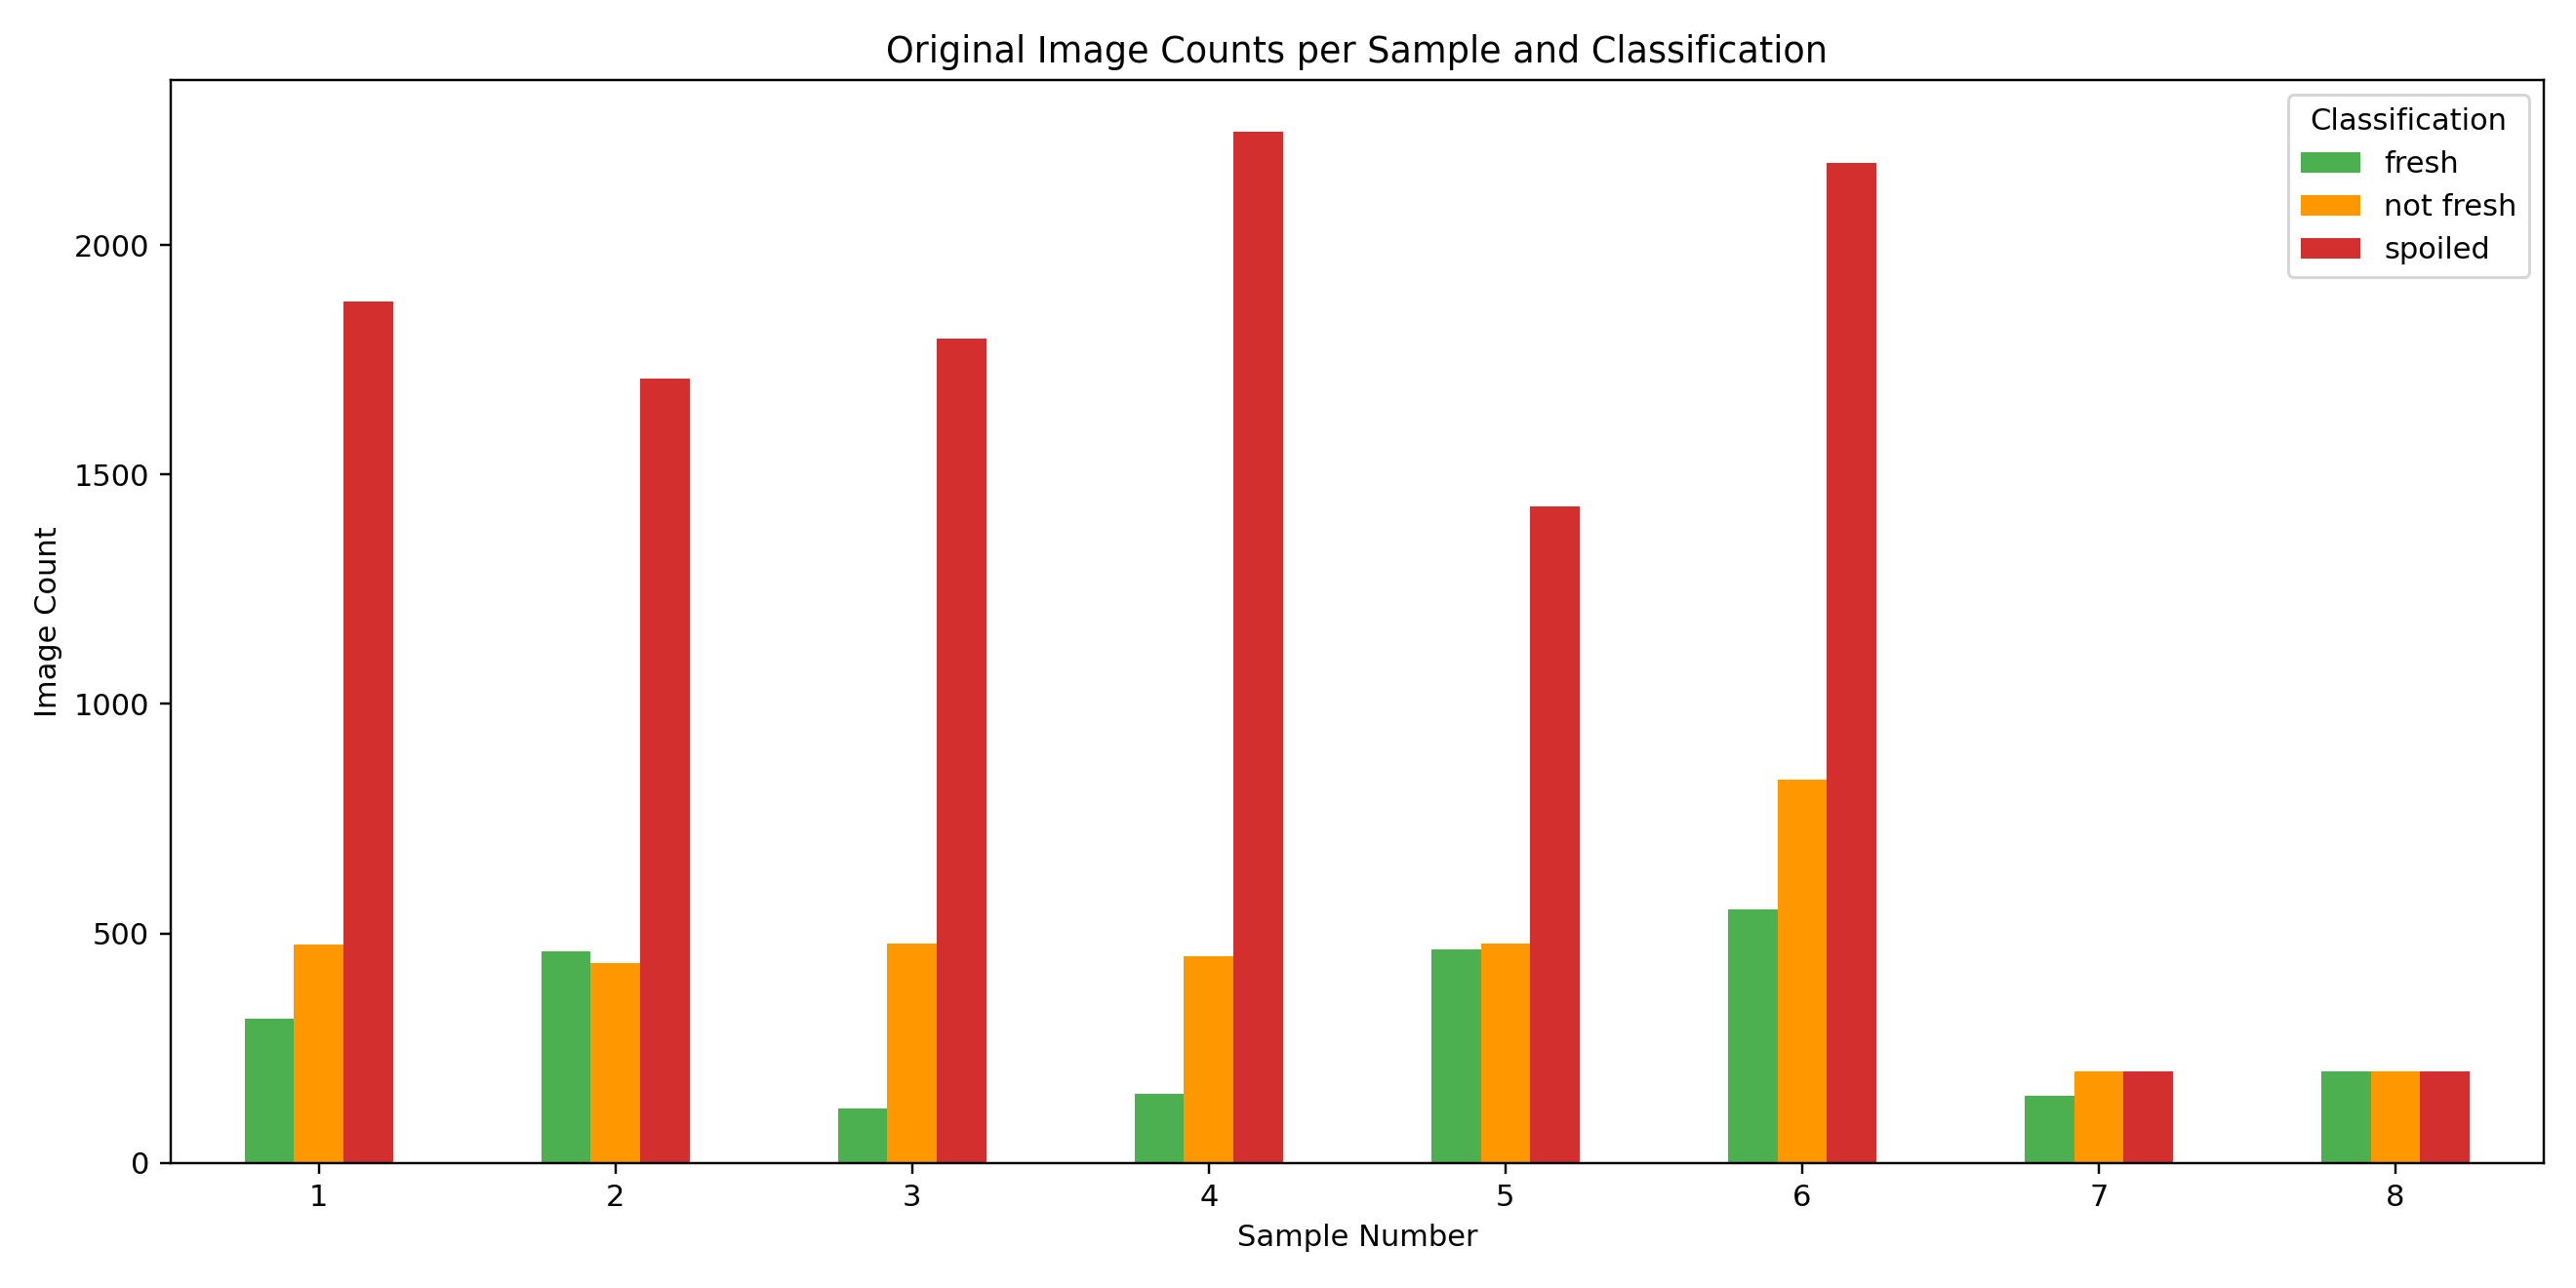

sampled_sample_label_counts: e:\Thesis Code\csv_outputs_interval_sampled_v5\plots\sampled_sample_label_counts.png


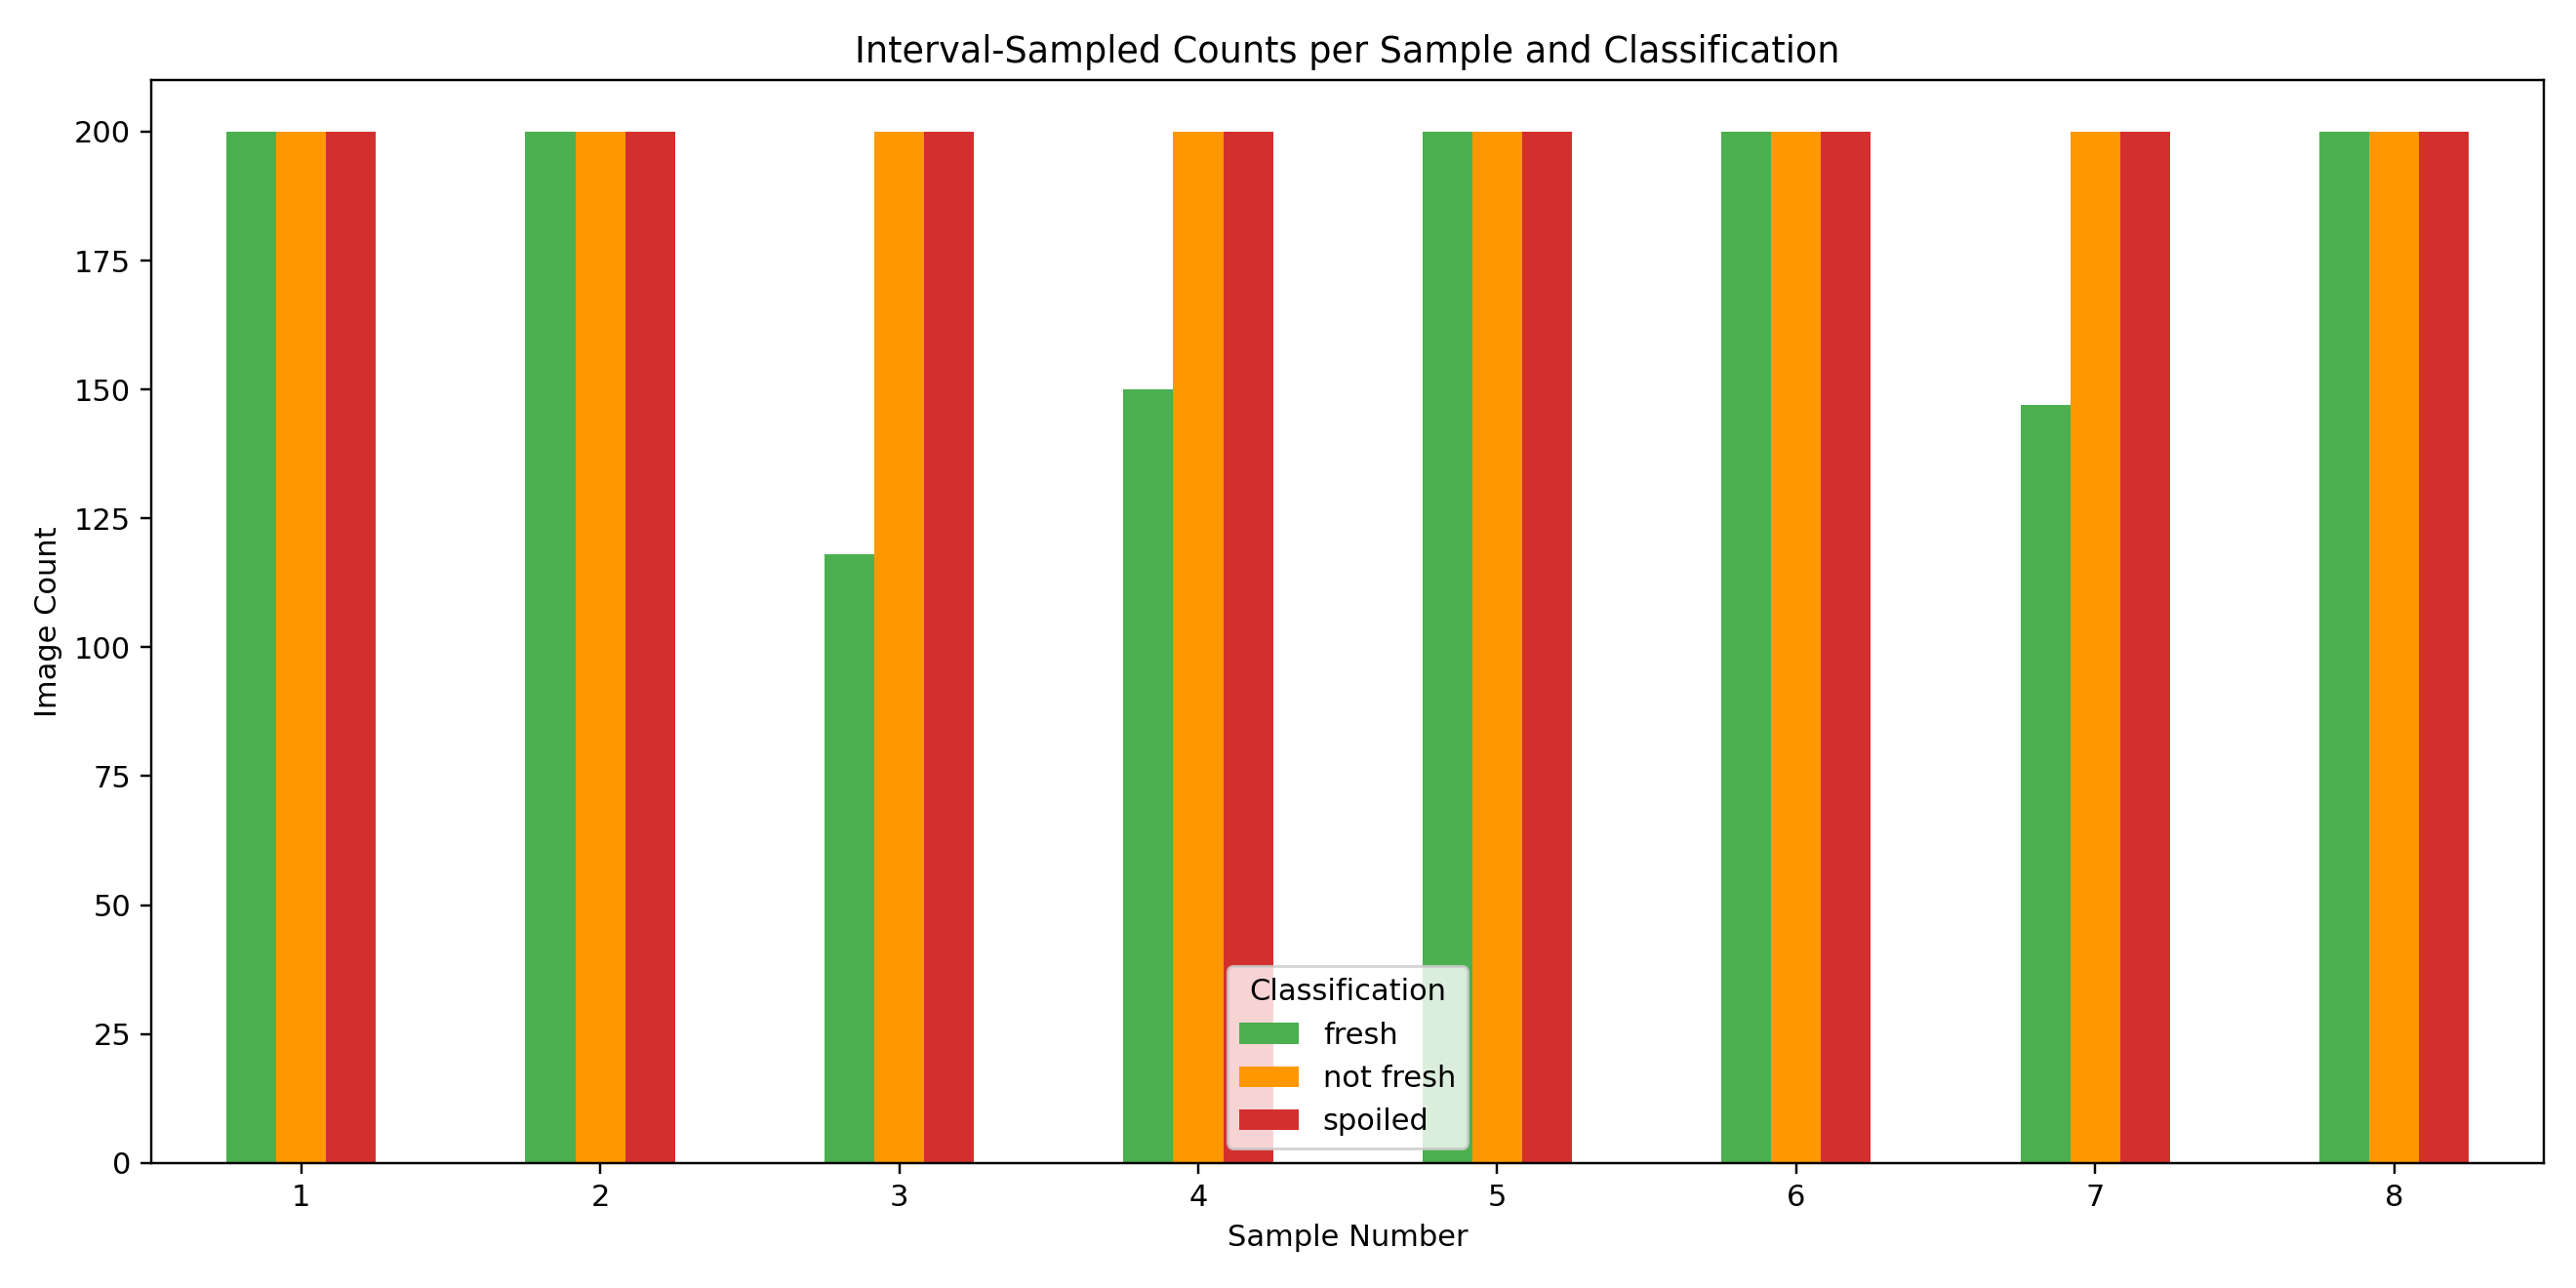

raw_vs_sampled_totals: e:\Thesis Code\csv_outputs_interval_sampled_v5\plots\raw_vs_sampled_totals.png


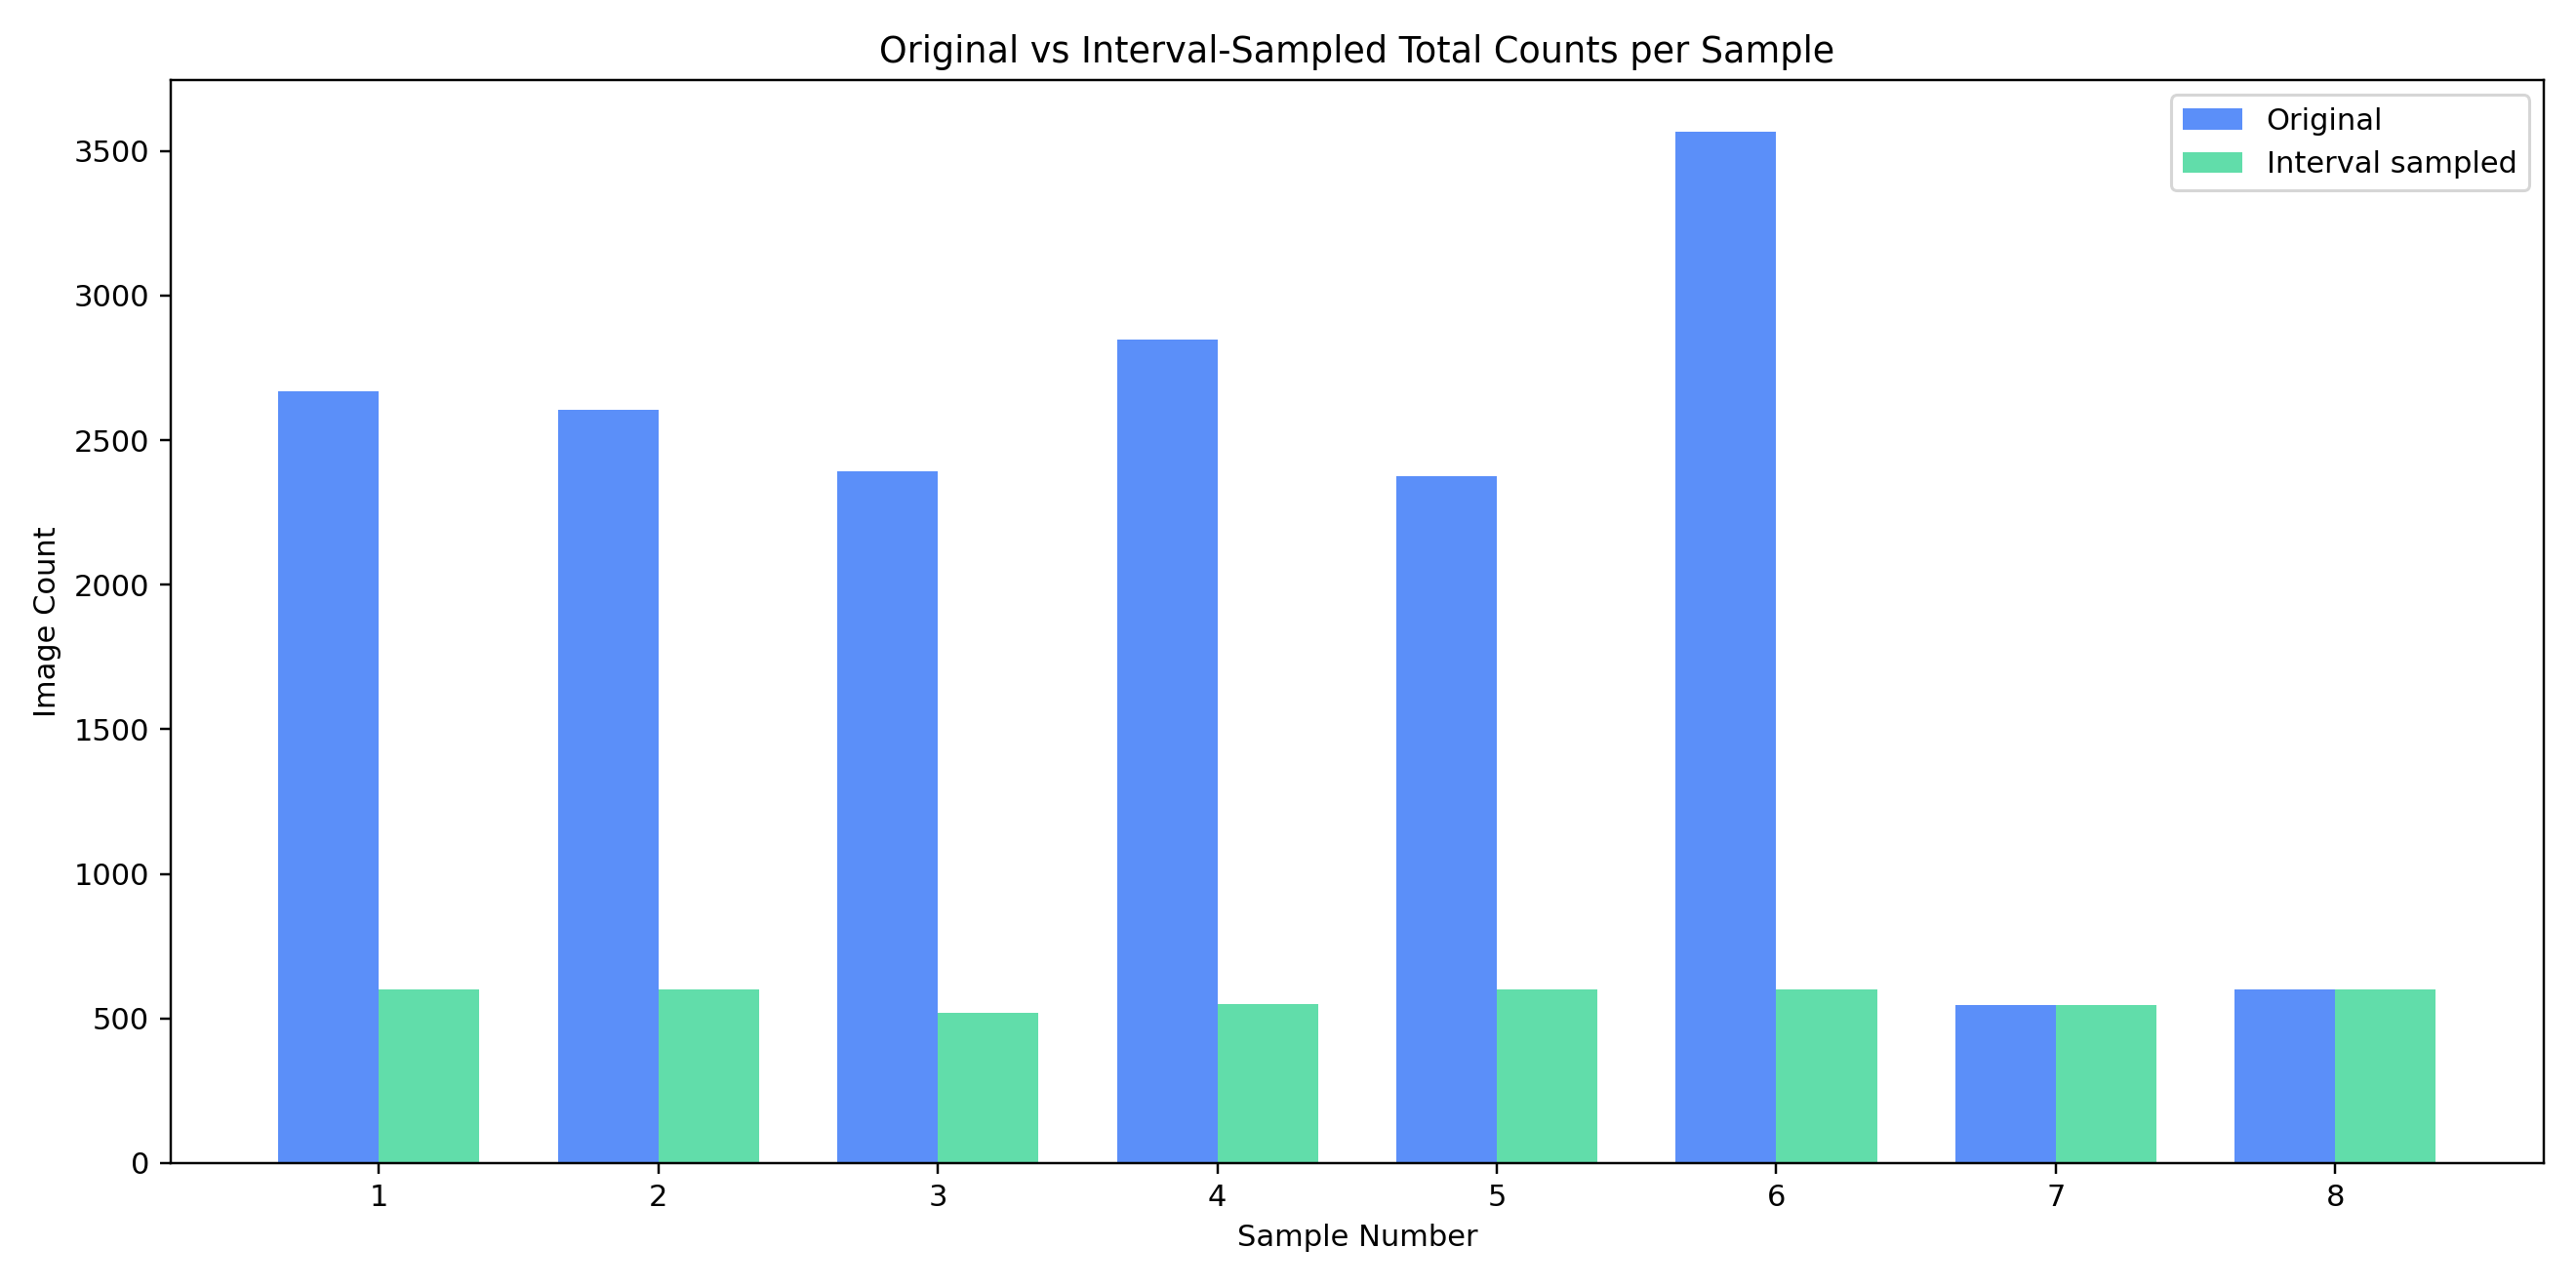

raw_vs_sampled_per_classification: e:\Thesis Code\csv_outputs_interval_sampled_v5\plots\raw_vs_sampled_per_classification.png


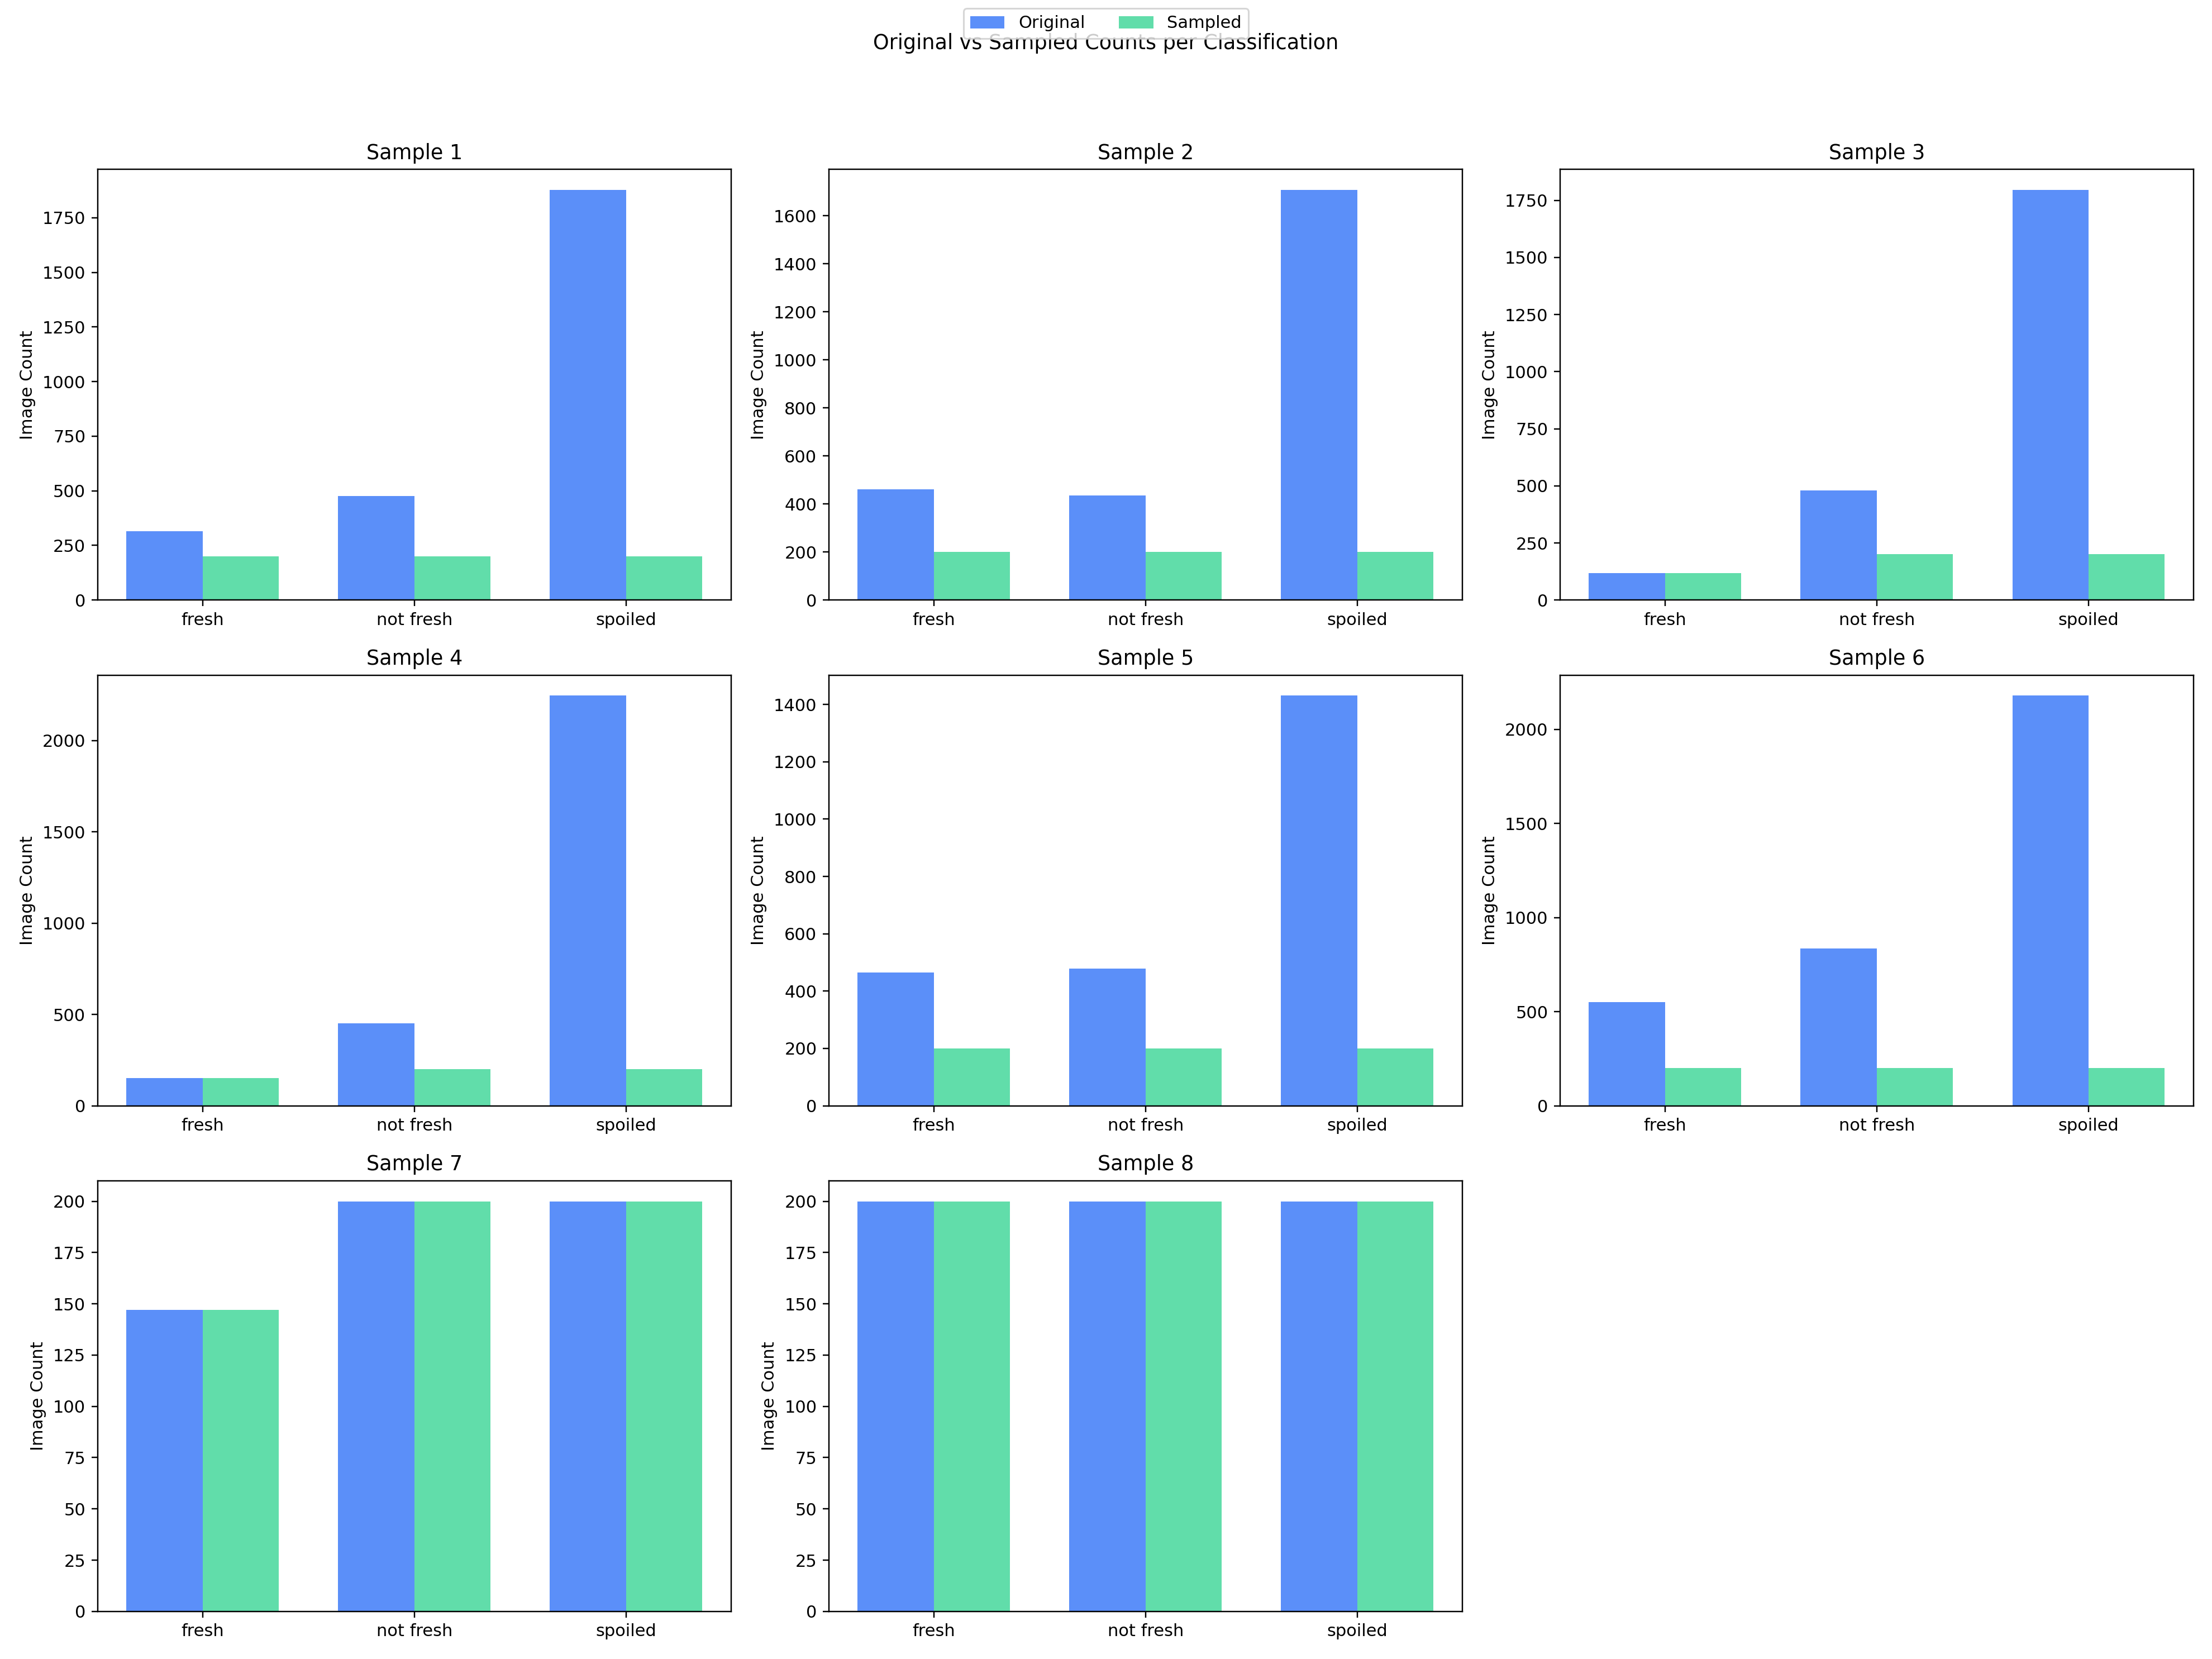

In [8]:
print("Saved plot files")
for plot_name, plot_path in outputs["plot_paths"].items():
    print(f"{plot_name}: {plot_path}")
    display(Image(filename=str(plot_path)))


In [9]:
print("Example processed split rows")
example_df = pd.read_csv(SPLIT_OUTPUT_DIR / "fold1_train.csv", dtype=str).fillna("")
display(example_df[["sample_number", "label", "image_file_name", "file_destination"]].head(20))


Example processed split rows


,sample_number,label,image_file_name,file_destination
0,2,fresh,IMG20260423061521.jpg,E:\Thesis Code\interval sampled\Pork Shoulder ...
1,3,fresh,20260429_042402.jpg,E:\Thesis Code\interval sampled\Pork Belly - S...
2,4,fresh,20260429_065044.jpg,E:\Thesis Code\interval sampled\Pork Belly - S...
3,5,fresh,IMG_20260508_041534.jpg,E:\Thesis Code\interval sampled\Pork Ham - Sam...
4,6,fresh,IMG20260508062349.jpg,E:\Thesis Code\interval sampled\Pork Ham - Sam...
5,7,fresh,IMG_20260517_093637.jpg,E:\Thesis Code\processed_hsv_lab_threshold_roi...
6,8,fresh,20260516_071353.jpg,E:\Thesis Code\processed_hsv_lab_threshold_roi...
7,2,fresh,IMG20260423061821.jpg,E:\Thesis Code\interval sampled\Pork Shoulder ...
8,6,fresh,IMG20260508062519.jpg,E:\Thesis Code\interval sampled\Pork Ham - Sam...
9,8,fresh,20260516_071452.jpg,E:\Thesis Code\processed_hsv_lab_threshold_roi...
